In [2]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split  # only for splitting
import matplotlib.pyplot as plt

In [4]:
dataset_path = "/home/deep/Documents/COVID"
img_size = (224, 224)  # Resize images for simplicity
class_labels = ['COVID positive', 'COVID negative']

In [6]:
def load_images(path, label):
    images = []
    labels = []
    for file in os.listdir(path):
        if file.endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(path, file)
            img = Image.open(img_path).convert('L')  # Convert to grayscale
            img = img.resize(img_size)
            images.append(np.array(img).flatten())
            labels.append(label)
    return images, labels


In [8]:
X = []
y = []

In [10]:
for label_idx, class_name in enumerate(class_labels):
    class_path = os.path.join(dataset_path, class_name)
    imgs, labels = load_images(class_path, label_idx)
    X.extend(imgs)
    y.extend(labels)

X = np.array(X)
y = np.array(y)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [62]:
class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def predict(self, X):
        y_pred = []
        for x in X:
            distances = [self.euclidean_distance(x, x_train) for x_train in self.X_train]
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            most_common = max(set(k_nearest_labels), key=k_nearest_labels.count)
            y_pred.append(most_common)
        return np.array(y_pred)


In [64]:
knn = KNNClassifier(k=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [65]:
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9359


In [66]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_labels))


Confusion Matrix:
 [[230  19]
 [ 13 237]]

Classification Report:
                 precision    recall  f1-score   support

COVID positive       0.95      0.92      0.93       249
COVID negative       0.93      0.95      0.94       250

      accuracy                           0.94       499
     macro avg       0.94      0.94      0.94       499
  weighted avg       0.94      0.94      0.94       499



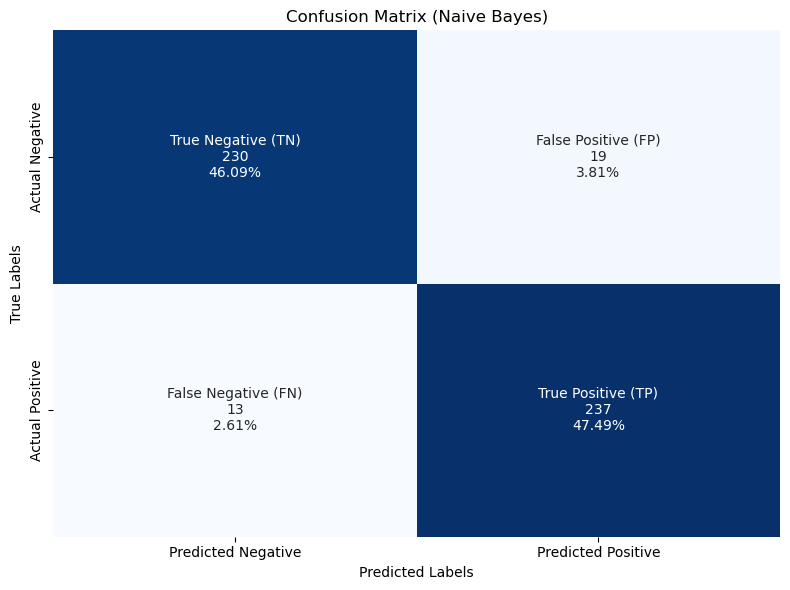


From Confusion Matrix:
Precision : 0.9258
Recall :    0.9480
F1 Score :  0.9368


In [67]:
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    group_names = ['True Negative (TN)', 'False Positive (FP)',
                   'False Negative (FN)', 'True Positive (TP)']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

    labels = [f"{name}\n{count}\n{percent}" for name, count, percent in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm, title="Confusion Matrix (Naive Bayes)")

def compute_metrics_from_cm(cm):
    TN, FP, FN, TP = cm.ravel()

    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

    return precision, recall, f1

# Calculate metrics
precision, recall, f1 = compute_metrics_from_cm(cm)
print(f"\nFrom Confusion Matrix:")
print(f"Precision : {precision:.4f}")
print(f"Recall :    {recall:.4f}")
print(f"F1 Score :  {f1:.4f}")
